In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

import numpy as np
import matplotlib.pyplot as plt
import time 

from src.parameters import Parameters
from src.acquisition import Acquisition
from src.forward import forward

np.random.seed(52)


In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,         # Use LaTeX
    "font.family": "serif",      # Use serif fonts
    "font.size": 18,             # Set font size
    "axes.labelsize": 18,        # Label font size
    "legend.fontsize": 18,       # Legend font size
    "xtick.labelsize": 18,       # X-axis tick size
    "ytick.labelsize": 18,       # Y-axis tick size
    "figure.figsize": (8,6),     # Set figure size
    "lines.linewidth": 1.5,        # Line thickness
    "grid.alpha": 0.5,           # Grid transparency
    "savefig.dpi": 300           # High-resolution images
})

In [3]:
nq_prop = 2048
nq_evan = 256

In [4]:
#vp1, vp2 = 1600., 2800.
#fs = True
#layers = [
#        (250.0, vp1, 2000.0), # top layer
#        (600.0, vp2, 2000.0),
#    ]

#sources = [(30., 76.)]
#receivers = [(1000, 76.)]
#param = Parameters(total_time=1.2, nt=512, freq=7., nfft=1024)
#acq = Acquisition(sources, receivers)

vp0, vp1, vp2 = 1600., 2800., 4800.
fs = True
layers = [
        (300.0, vp0, 2000.0),
        (350.0, vp1, 2000.0), # top layer
        (500.0, vp2, 2000.0),
    ]

sources = [(30., 76.)]
receivers = [(1800, 76.)]
param = Parameters(total_time=2.0, nt=256, freq=5., nfft=512)
acq = Acquisition(sources, receivers)

In [5]:
# generate observations
d_obs = forward(layers, acq, param, free_surface=fs, nq_prop=nq_prop, nq_evan=nq_evan)
Nt = len(param.time)
trace = d_obs[0, 0, :]
ampli = np.max(trace)
std_noise = ampli/15.
trace_noise = trace #+ np.random.normal(loc=0, scale=std_noise, size=Nt)
print('Signal-to-noise ratio :', np.max(np.abs(trace_noise)) / std_noise)

Signal-to-noise ratio : 18.07300258719962


In [6]:
def l2_misfit(dcal, dobs, std_noise):
    return 0.5 * np.sum((dcal - dobs)**2) / param.dt #/ (std_noise**2)

L2_Err = l2_misfit(trace_noise, trace, std_noise)
print("misfit = ", L2_Err)

misfit =  0.0


In [14]:
#c1, c2 = 1360., 1800.
#layers_test = [
#        (250.0, c1, 2000.0), # top layer
#        (600.0, c2, 2000.0),
#    ]

layers_test = [
        (300.0, 1750., 2000.0),
        (350.0, 4200., 2000.0), # top layer
        (500.0, 3500., 2000.0),
    ]
d_obs_test = forward(layers_test, acq, param, free_surface=fs, nq_prop=nq_prop, nq_evan=nq_evan)
trace_test = d_obs_test[0, 0, :]

misfit =  4.875488765764438


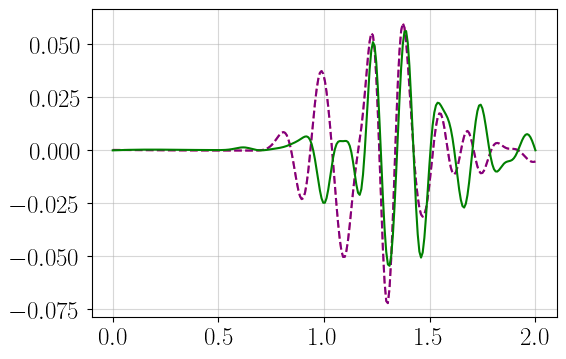

In [15]:
plt.figure(figsize=(6,4))
plt.plot(param.time, trace, 'r--', label='observed - reference')
plt.plot(param.time, trace_noise, 'b--', alpha = 0.5, label='observed - noisy')
plt.plot(param.time, trace_test, 'g-', alpha = 1., label='observed - noisy')
#plt.legend()
plt.grid()

L2_Err = l2_misfit(trace, trace_test, std_noise) 
print("misfit = ", L2_Err)#/std_noise**2)

In [9]:
#vp_min, vp_max, npts = 1000, 2500, 80
#vp_min2, vp_max2 = 1000, 4000

#vp_min, vp_max, npts = 1500, 4000, 60
#vp_min2, vp_max2 = 2000, 7000

vp_min, vp_max, npts = 1000, 2500, 80
vp_min2, vp_max2 = 2500, 5000

x_vals = np.linspace(vp_min, vp_max, npts)
y_vals = np.linspace(vp_min2, vp_max2, npts)
xgrid, ygrid = np.meshgrid(x_vals, y_vals, indexing='ij')
COST = np.empty_like(xgrid)

start_time = time.time()
for i in range(npts):
    for j in range(npts):
        point = np.array([xgrid[i, j], ygrid[i, j]])
        #layers = [(250.0, point[0], 2000.0),(600.0, point[1], 2000.0)]
        # layers = [(300.0, 1600., 2000.0),(350.0, point[0], 2000.0),(500.0, point[1], 2000.0)]
        layers = [(300.0, point[0], 2000.0),(350.0, point[1], 2000.0),(500.0, 4800., 2000.0)]
        dcal_tmp = forward(layers, acq, param, free_surface=fs, nq_prop=nq_prop, nq_evan=nq_evan)
        COST[i,j] = l2_misfit(dcal_tmp, trace, std_noise)

elapsed_time = time.time() - start_time
print(f"generated misfit map in {elapsed_time:.3f} seconds.")

generated misfit map in 958.643 seconds.


In [16]:
def create_plot(X, Y, Z):
    plt.figure(figsize=(8, 5))
    contour_lines = plt.contour(X, Y, Z, levels=24, 
                                    colors="black", linewidths=1., linestyles="dotted")
    plt.clabel(contour_lines, inline=True, fontsize=6, fmt="%.2f")  # Add isovalue labels
    plt.contourf(X, Y, Z, levels=24, cmap="viridis_r")
    plt.colorbar(label="$L^2$ misfit", aspect=50)
    plt.scatter(vp0, vp1, s=115, c="red", marker='*', alpha=1, edgecolors='k')
    plt.xlabel(r'$V_{P,1}$ [m/s]')
    plt.ylabel(r'$V_{P,2}$ [m/s]')
    #plt.xlim([1000, 2500])
    #plt.ylim([1000, 4000])
    plt.xlim([1000, 2500])
    plt.ylim([2500, 5000])
    plt.tight_layout()
    plt.show()

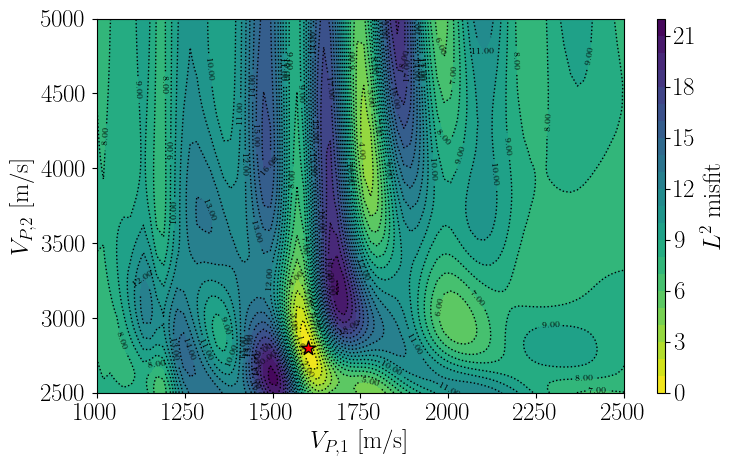

In [17]:
create_plot(xgrid, ygrid, COST)

In [33]:
def gaussian_prior_2d(xgrid, ygrid, mean, std):
    mean = np.asarray(mean)
    std = np.asarray(std)
    # Normalization constant
    norm = 1.0 / (2 * np.pi * std[0] * std[1])
    # Compute exponent
    dx = (xgrid - mean[0]) / std[0]
    dy = (ygrid - mean[1]) / std[1]
    exponent = -0.5 * (dx**2 + dy**2)
    return np.exp(exponent)

vp_mean = [1600., 3000.]
std = [500, 1000]   # sqrt of diagonal cov
# Compute prior
prior = gaussian_prior_2d(xgrid, ygrid, vp_mean, std)
# Compute posterior
likelihood = np.exp(-(COST/np.max(COST)))
print("max", np.max(COST))
posterior = prior * likelihood

max 21.426375656513358


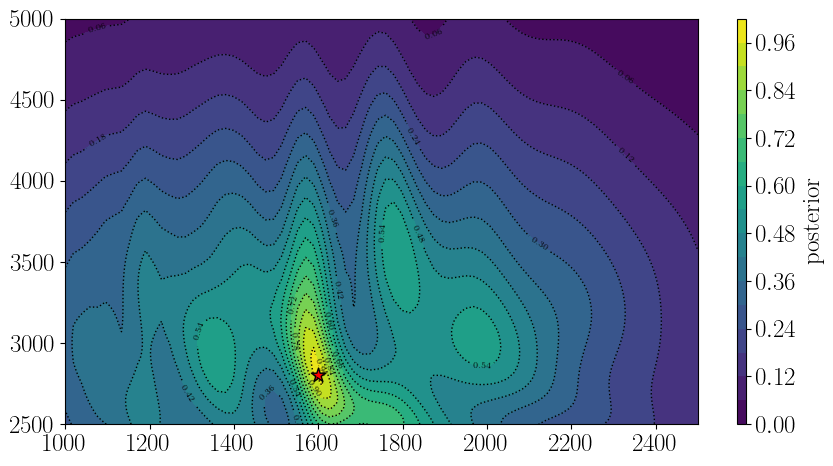

In [40]:
plt.figure(figsize=(9, 5))
contour_lines = plt.contour(xgrid, ygrid, posterior, levels=16, 
                                    colors="black", linewidths=1., linestyles="dotted")
plt.clabel(contour_lines, inline=True, fontsize=6, fmt="%.2f")  # Add isovalue labels
plt.contourf(xgrid, ygrid, posterior, levels=16, cmap="viridis")
plt.colorbar(label="posterior", aspect=50)
plt.scatter(1600, 2800, s=115, c="red", marker='*', alpha=1, edgecolors='k')
plt.xlim([1000, 2500])
plt.ylim([2500, 5000])
plt.tight_layout()
plt.show()